In [65]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [25]:
# LOADING DATASETS
weather=pd.read_csv("data/Weather.csv")
production=pd.read_csv("data/Production.csv")
survey=pd.read_csv("data/State.csv")


In [26]:
# CLEANING DATA
weather.columns=weather.columns.str.strip().str.lower()
weather.rename(columns={
    'temp_mean(c)':'temp_mean',
    'temp_min(c)':'temp_min',
    'temp_max(c)':'temp_max'
}, inplace=True)

print(weather.isnull().sum())
weather.ffill( inplace=True)

pressure            0
global_radiation    0
temp_mean           0
temp_min            0
temp_max            0
wind_speed          0
wind_bearing        0
normalized_label    0
dtype: int64


,pressure,global_radiation,temp_mean,temp_min,temp_max,wind_speed,wind_bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.00,0,0
1,972.3,0.97,10.5,6.7,13.5,0.00,0,0
2,972.4,0.74,6.5,3.9,9.1,0.00,0,0
3,973.2,0.15,5.1,3.7,7.7,0.00,0,0
4,975.7,0.12,5.2,2.6,8.3,0.00,0,0
...,...,...,...,...,...,...,...,...
533307,1015.0,2.11,19.7,15.0,27.3,3.14,325,0
533308,1015.0,2.11,19.7,15.0,27.3,24.07,147,2
533309,1015.0,2.11,19.7,15.0,27.3,3.30,247,0
533310,1015.0,2.11,19.7,15.0,27.3,25.41,308,2


In [27]:
production.head()

,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


In [28]:
production.columns=production.columns.str.strip()
production.dropna(inplace=True)

In [29]:
survey.columns=survey.columns.str.strip().str.lower()

In [30]:
# Basic EDA

In [31]:
print(weather.head())

   pressure  global_radiation  temp_mean  temp_min  temp_max  wind_speed  \
0     971.5              0.25        9.0       7.0      10.7         0.0   
1     972.3              0.97       10.5       6.7      13.5         0.0   
2     972.4              0.74        6.5       3.9       9.1         0.0   
3     973.2              0.15        5.1       3.7       7.7         0.0   
4     975.7              0.12        5.2       2.6       8.3         0.0   

   wind_bearing  normalized_label  
0             0                 0  
1             0                 0  
2             0                 0  
3             0                 0  
4             0                 0  


In [32]:
print(production.head())

   Dist Code  Year  State Code    State Name Dist Name  RICE AREA (1000 ha)  \
0          1  1966          14  Chhattisgarh      Durg                548.0   
1          1  1967          14  Chhattisgarh      Durg                547.0   
2          1  1968          14  Chhattisgarh      Durg                556.3   
3          1  1969          14  Chhattisgarh      Durg                563.4   
4          1  1970          14  Chhattisgarh      Durg                571.6   

   RICE PRODUCTION (1000 tons)  RICE YIELD (Kg per ha)  WHEAT AREA (1000 ha)  \
0                        185.0                  337.59                  44.0   
1                        409.0                  747.71                  50.0   
2                        468.0                  841.27                  53.7   
3                        400.8                  711.40                  49.4   
4                        473.6                  828.55                  44.2   

   WHEAT PRODUCTION (1000 tons)  ...  SUGARC

In [33]:
print(weather.describe())

            pressure  global_radiation      temp_mean       temp_min  \
count  533312.000000     533312.000000  533312.000000  533312.000000   
mean     1011.436192          1.310346      12.646057       8.648474   
std         3.241187          0.897191       6.519240       5.867740   
min       971.500000          0.030000     -11.100000     -16.000000   
25%      1009.800000          0.510000       7.800000       4.500000   
50%      1012.300000          1.160000      13.200000       9.400000   
75%      1013.900000          2.010000      17.500000      13.300000   
max      1015.000000          3.600000      28.600000      22.000000   

            temp_max     wind_speed   wind_bearing  normalized_label  
count  533312.000000  533312.000000  533312.000000     533312.000000  
mean       16.871960      11.885974     192.501742          0.906152  
std         7.692881       7.677086     101.984936          0.992549  
min        -8.500000       0.000000       0.000000          0.00000

In [34]:
print(production.describe())

          Dist Code          Year    State Code  RICE AREA (1000 ha)  \
count  16146.000000  16146.000000  16146.000000         16146.000000   
mean     269.769231   1991.496841      9.568562           128.593192   
std      278.309125     15.011185      4.988538           160.078825   
min        1.000000   1966.000000      1.000000            -1.000000   
25%       78.000000   1978.000000      6.000000            10.400000   
50%      156.000000   1991.000000     10.000000            66.800000   
75%      241.000000   2005.000000     12.000000           191.390000   
max      917.000000   2017.000000     20.000000          1154.230000   

       RICE PRODUCTION (1000 tons)  RICE YIELD (Kg per ha)  \
count                 16146.000000            16146.000000   
mean                    224.889565             1486.924784   
std                     326.629828              956.185281   
min                      -1.000000               -1.000000   
25%                       9.460000       

In [35]:
# Weather Analysis

In [36]:
## Temperature Distribution

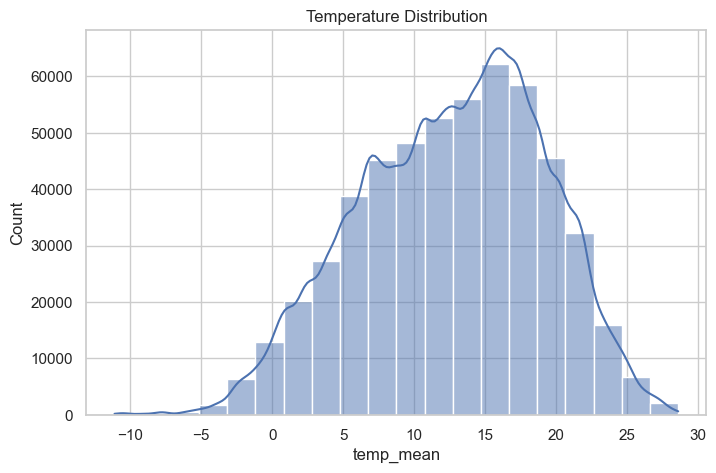

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(weather['temp_mean'],bins=20,kde=True)
plt.title("Temperature Distribution")
plt.savefig('Reports/Temperature_Distribution.png')
plt.show()


In [41]:
## Temperature vs Risk

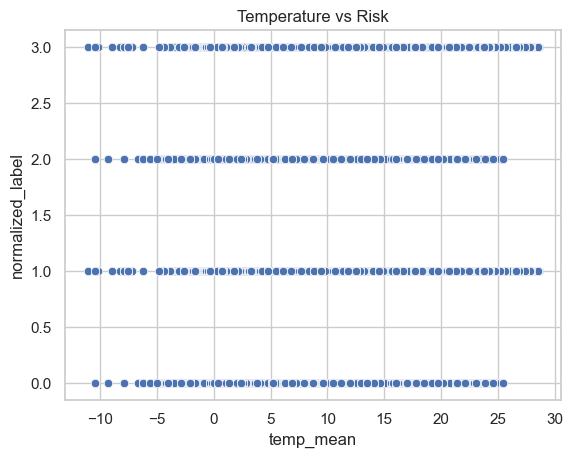

In [71]:
sns.scatterplot(x='temp_mean', y='normalized_label', data=weather)
plt.title("Temperature vs Risk")
plt.savefig('Reports/Temperature vs Risk.png')
plt.show()

In [43]:
## Radiation impact

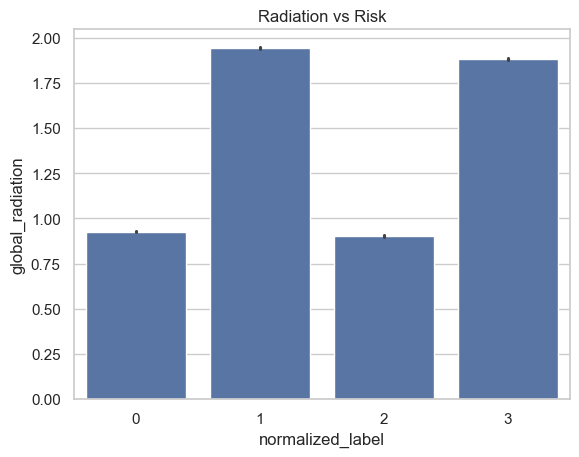

In [72]:
sns.barplot(x='normalized_label', y='global_radiation', data=weather)
plt.title("Radiation vs Risk")
plt.savefig('Reports/Radiation vs Risk.png')
plt.show()

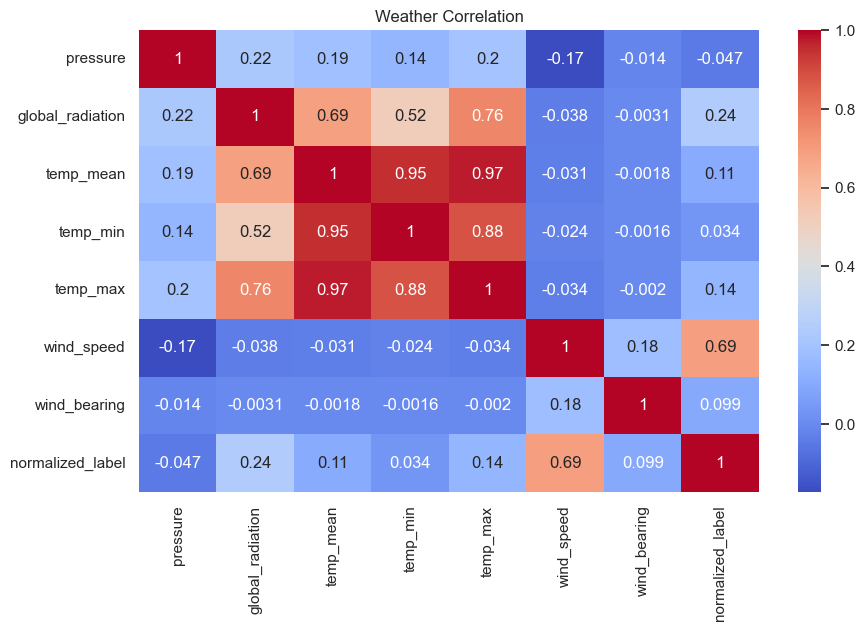

In [73]:
plt.figure(figsize=(10,6))
sns.heatmap(weather.corr(), annot=True, cmap='coolwarm')
plt.title("Weather Correlation")
plt.savefig('Reports/Weather Correlation.png')
plt.show()

In [47]:
# Production Analysis

In [48]:
## Rice Production Trend

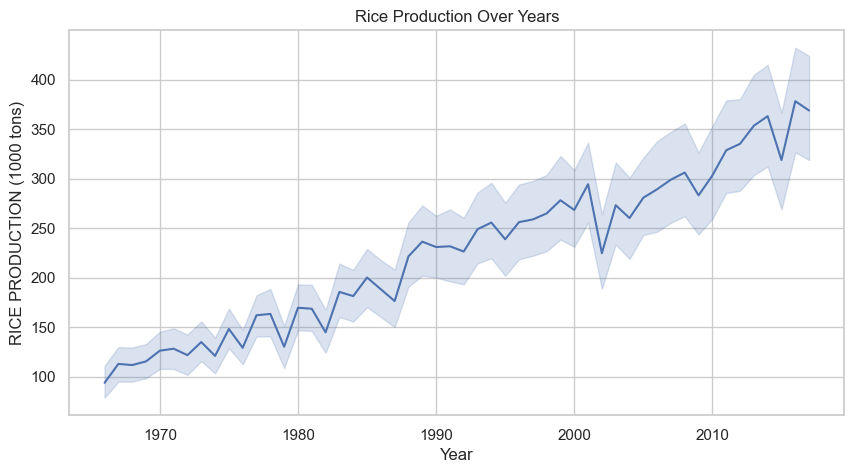

In [74]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='RICE PRODUCTION (1000 tons)', data=production)
plt.title("Rice Production Over Years")
plt.savefig('Reports/Rice Production Over Years.png')
plt.show()

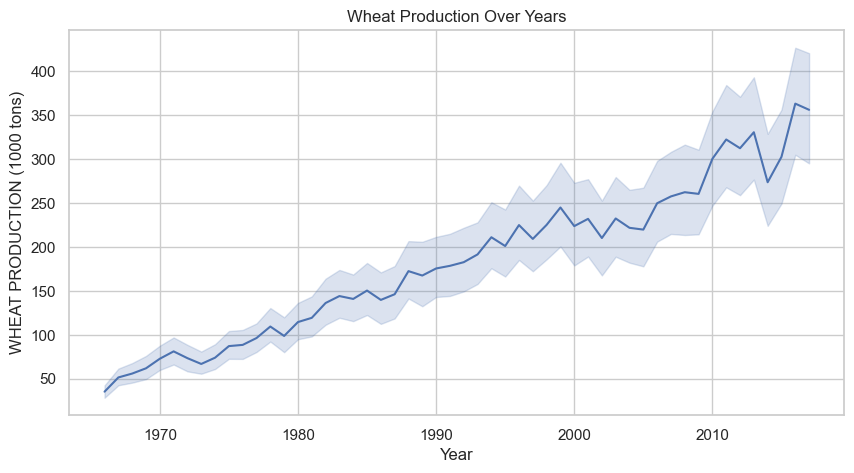

In [75]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='WHEAT PRODUCTION (1000 tons)', data=production)
plt.title("Wheat Production Over Years")
plt.savefig('Reports/Wheat Production Over Years.png')
plt.show()

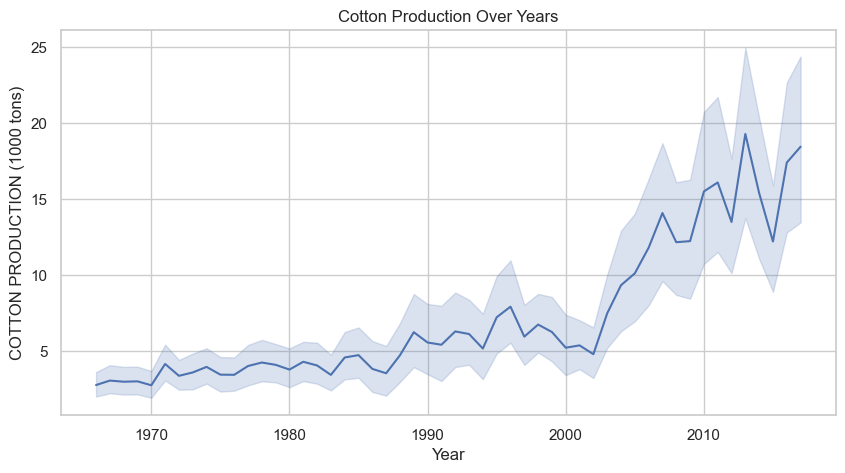

In [76]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='COTTON PRODUCTION (1000 tons)', data=production)
plt.title("Cotton Production Over Years")
plt.savefig('Reports/Cotton Production Over Years.png')
plt.show()

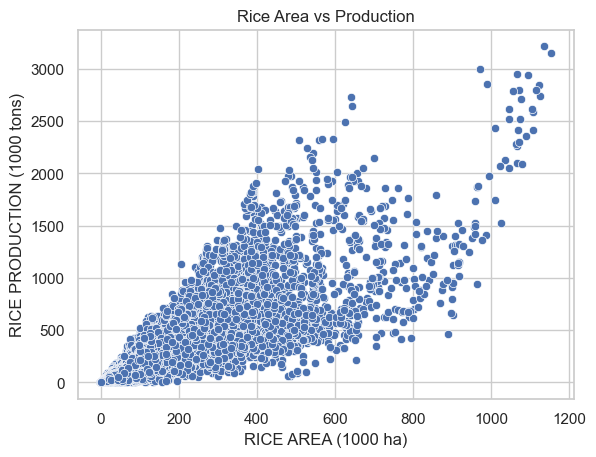

In [77]:
sns.scatterplot(
    x='RICE AREA (1000 ha)',
    y='RICE PRODUCTION (1000 tons)',
    data=production
)
plt.title("Rice Area vs Production")
plt.savefig('Reports/Rice Area vs Production')
plt.show()

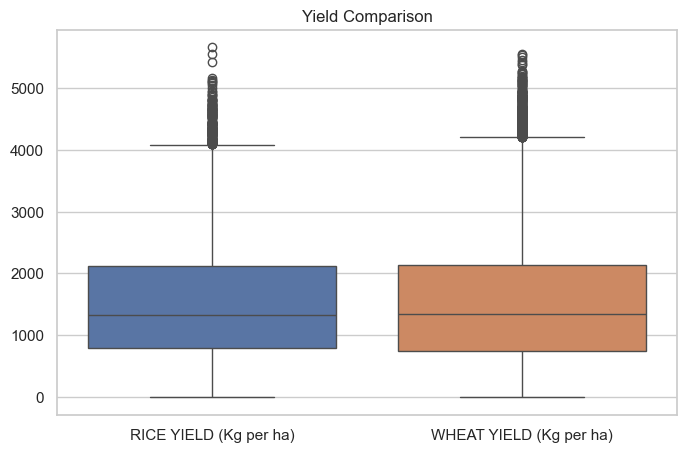

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(data=production[[
    'RICE YIELD (Kg per ha)',
    'WHEAT YIELD (Kg per ha)'
]])
plt.title("Yield Comparison")
plt.savefig('Reports/Yield Comparison.png')
plt.show()

In [55]:
# Risk Distribution

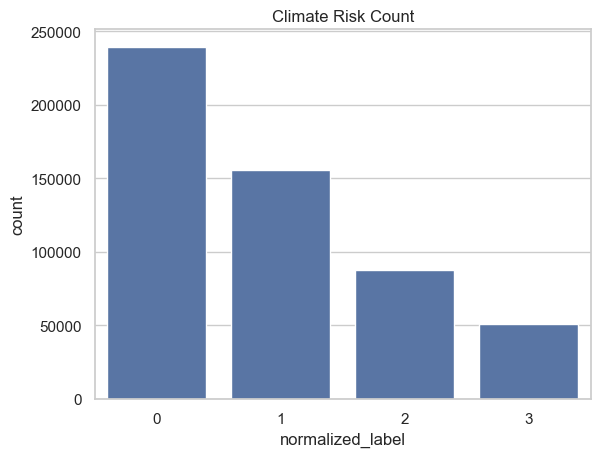

In [79]:
sns.countplot(x='normalized_label',data=weather)
plt.title("Climate Risk Count")
plt.savefig('Reports/Climate Risk Count.png')
plt.show()

In [57]:
# Production Stability

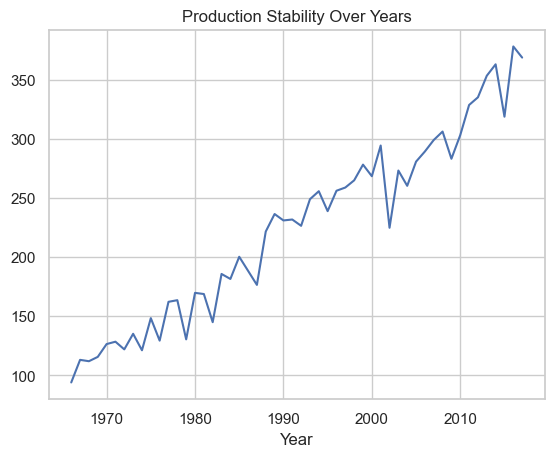

In [80]:
production.groupby('Year')['RICE PRODUCTION (1000 tons)'].mean().plot()
plt.title("Production Stability Over Years")
plt.savefig('Reports/Production Stability Over Years.png')
plt.show()

In [60]:
# Mean temperature
mean_temp = np.mean(weather['temp_mean'])
print("Average Temperature:", mean_temp)

# Std deviation (variation)
std_temp = np.std(weather['temp_mean'])
print("Temperature Variation:", std_temp)

Average Temperature: 12.646056904776191
Temperature Variation: 6.519233714091767


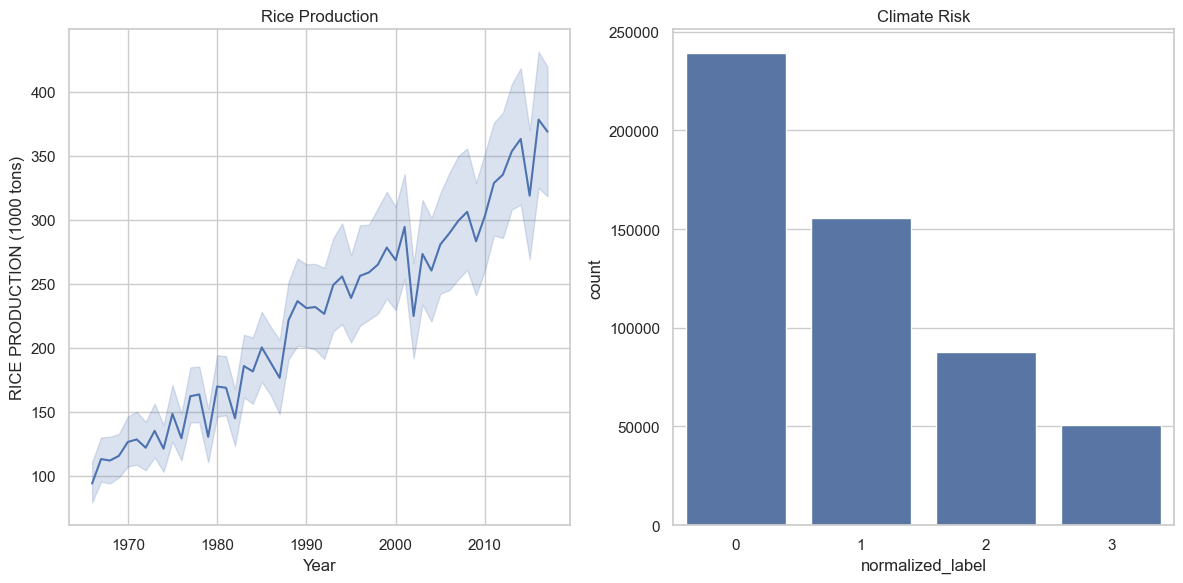

In [81]:
# FINAL VISUAL DASHBOARD

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.lineplot(x='Year', y='RICE PRODUCTION (1000 tons)', data=production)
plt.title("Rice Production")

plt.subplot(1,2,2)
sns.countplot(x='normalized_label', data=weather)
plt.title("Climate Risk")

plt.tight_layout()
plt.savefig('Reports/FINAL VISUAL DASHBOARD.png')
plt.show()

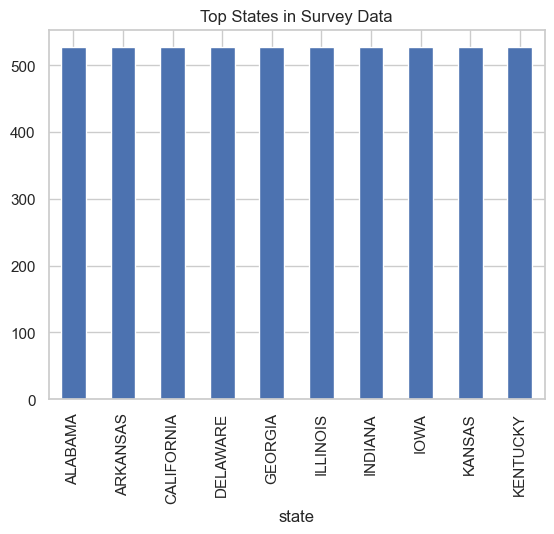

In [82]:
survey['state'].value_counts().head(10).plot(kind='bar')
plt.title("Top States in Survey Data")
plt.savefig('Reports/Top States in Survey Data.png')
plt.show()